1. Create the Dataset

Define the input (X) and output (y) arrays for all four XOR combinations.

In [1]:
import numpy as np

# XOR input data
X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
], dtype=np.float32)

# XOR output
y = np.array([
    [0],
    [1],
    [1],
    [0]
], dtype=np.float32)

print("Input:")
print(X)

print("\nOutput:")
print(y)

Input:
[[0. 0.]
 [0. 1.]
 [1. 0.]
 [1. 1.]]

Output:
[[0.]
 [1.]
 [1.]
 [0.]]


Step 2 — Build the MLP

According to your question:

Input layer → 2 inputs
Hidden layer → at least 2 neurons
Activation → Tanh
Output layer → 1 neuron
Output activation → Sigmoid

We'll use 4 neurons in the hidden layer because XOR is a nonlinear problem.

In [2]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

model = keras.Sequential([
    layers.Input(shape=(2,)),
    layers.Dense(4, activation='tanh'),
    layers.Dense(1, activation='sigmoid')
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 4)              │            12 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17 (68.00 B)

 Trainable params: 17 (68.00 B)

 Non-trainable params: 0 (0.00 B)

Step 3 — Compile the Model

Your lab specifically requires Binary Cross-Entropy and allows Adam or SGD.

We'll use Adam.

In [3]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.1),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

Step 4 — Train the Model

Your lab asks you to train the model and experiment with epochs, learning rate and number of neurons.

For the first experiment, use:

Epochs = 500
Learning rate = 0.1
Hidden neurons = 4

In [4]:
history = model.fit(
    X,
    y,
    epochs=500,
    verbose=0
)

print("Training completed.")

Training completed.


In [5]:
history = model.fit(
    X,
    y,
    epochs=500,
    verbose=1
)

Epoch 1/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 1.0000 - loss: 2.4006e-04
Epoch 2/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 1.0000 - loss: 2.3914e-04
Epoch 3/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 1.0000 - loss: 2.3823e-04
Epoch 4/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 1.0000 - loss: 2.3732e-04
Epoch 5/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 1.0000 - loss: 2.3642e-04
Epoch 6/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 1.0000 - loss: 2.3553e-04
Epoch 7/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 1.0000 - loss: 2.3464e-04
Epoch 8/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 1.0000 - loss: 2.3375e-04
Epoch 9/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 1.0000 - loss: 2.3287e-04
Epoch 10/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 1.0000 - loss: 2.3200e-04
Epoch 11/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 1.0000 - loss: 2.3113e-04
Epoch 12/500
1/1 ━━━━━━━━━━━━━

Step 5 — Evaluate the Model

The lab requires predictions for all four XOR combinations.

Calculate accuracy

In [6]:
loss, accuracy = model.evaluate(X, y, verbose=0)

print("Loss:", loss)
print("Accuracy:", accuracy)

Loss: 6.812950596213341e-05
Accuracy: 1.0


In [7]:
predictions = model.predict(X, verbose=0)

print("\nPredictions:")

for i in range(len(X)):
    probability = predictions[i][0]

    if probability >= 0.5:
        predicted_output = 1
    else:
        predicted_output = 0

    print(
        "Input:", X[i].astype(int),
        "Probability:", round(float(probability), 4),
        "Predicted:", predicted_output,
        "Actual:", int(y[i][0])
    )


Predictions:
Input: [0 0] Probability: 0.0 Predicted: 0 Actual: 0
Input: [0 1] Probability: 0.9999 Predicted: 1 Actual: 1
Input: [1 0] Probability: 0.9999 Predicted: 1 Actual: 1
Input: [1 1] Probability: 0.0001 Predicted: 0 Actual: 0


Step 6 — TensorFlow Low-Level API

Now repeat the same XOR problem using TensorFlow directly.

In [8]:
import tensorflow as tf
import numpy as np

# =========================
# XOR Dataset
# =========================

X = tf.constant([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
], dtype=tf.float32)

y = tf.constant([
    [0],
    [1],
    [1],
    [0]
], dtype=tf.float32)


# =========================
# Define Weights and Biases
# =========================

W1 = tf.Variable(tf.random.normal([2, 4]))
b1 = tf.Variable(tf.zeros([4]))

W2 = tf.Variable(tf.random.normal([4, 1]))
b2 = tf.Variable(tf.zeros([1]))


# =========================
# Forward Propagation
# =========================

def forward(X):
    hidden = tf.tanh(tf.matmul(X, W1) + b1)
    output = tf.sigmoid(tf.matmul(hidden, W2) + b2)
    return output


# =========================
# Loss Function
# =========================

def loss_function(y_true, y_pred):
    return tf.reduce_mean(
        tf.keras.losses.binary_crossentropy(y_true, y_pred)
    )


# =========================
# Optimizer
# =========================

optimizer = tf.keras.optimizers.Adam(learning_rate=0.1)


# =========================
# Training
# =========================

for epoch in range(1000):

    with tf.GradientTape() as tape:

        predictions = forward(X)

        loss = loss_function(y, predictions)

    gradients = tape.gradient(
        loss,
        [W1, b1, W2, b2]
    )

    optimizer.apply_gradients(
        zip(
            gradients,
            [W1, b1, W2, b2]
        )
    )

    if (epoch + 1) % 100 == 0:
        print(
            "Epoch:",
            epoch + 1,
            "Loss:",
            float(loss)
        )


# =========================
# Final Predictions
# =========================

predictions = forward(X)

print("\nXOR Predictions:")

for i in range(4):

    probability = float(predictions[i][0])

    predicted_class = 1 if probability >= 0.5 else 0

    print(
        "Input:",
        X[i].numpy().astype(int),
        "Probability:",
        round(probability, 4),
        "Predicted:",
        predicted_class,
        "Actual:",
        int(y[i][0])
    )

Epoch: 100 Loss: 0.0017897451762109995
Epoch: 200 Loss: 0.0006491633248515427
Epoch: 300 Loss: 0.00036574926343746483
Epoch: 400 Loss: 0.00024079071590676904
Epoch: 500 Loss: 0.0001727809722069651
Epoch: 600 Loss: 0.00013097605551593006
Epoch: 700 Loss: 0.00010319661669200286
Epoch: 800 Loss: 8.36442195577547e-05
Epoch: 900 Loss: 6.929315713932738e-05
Epoch: 1000 Loss: 5.841450911248103e-05

XOR Predictions:
Input: [0 0] Probability: 0.0001 Predicted: 0 Actual: 0
Input: [0 1] Probability: 1.0 Predicted: 1 Actual: 1
Input: [1 0] Probability: 0.9999 Predicted: 1 Actual: 1
Input: [1 1] Probability: 0.0001 Predicted: 0 Actual: 0


Step 7 — Hyperparameter Experiment

Your lab specifically asks you to experiment with:

Epochs
Learning rate
Number of neurons
Activation functions

In [9]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# ==========================================
# XOR DATASET
# ==========================================

X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
], dtype=np.float32)

y = np.array([
    [0],
    [1],
    [1],
    [0]
], dtype=np.float32)


# ==========================================
# HYPERPARAMETER EXPERIMENTS
# ==========================================

experiments = [
    {
        "name": "Experiment 1",
        "neurons": 2,
        "activation": "tanh",
        "learning_rate": 0.1,
        "epochs": 500
    },
    {
        "name": "Experiment 2",
        "neurons": 4,
        "activation": "tanh",
        "learning_rate": 0.1,
        "epochs": 500
    },
    {
        "name": "Experiment 3",
        "neurons": 8,
        "activation": "tanh",
        "learning_rate": 0.1,
        "epochs": 500
    },
    {
        "name": "Experiment 4",
        "neurons": 4,
        "activation": "tanh",
        "learning_rate": 0.01,
        "epochs": 1000
    },
    {
        "name": "Experiment 5",
        "neurons": 4,
        "activation": "relu",
        "learning_rate": 0.1,
        "epochs": 500
    }
]


# ==========================================
# RUN EXPERIMENTS
# ==========================================

for exp in experiments:

    print("\n" + "=" * 50)
    print(exp["name"])
    print("=" * 50)

    # Build model
    model = keras.Sequential([
        layers.Input(shape=(2,)),
        layers.Dense(
            exp["neurons"],
            activation=exp["activation"]
        ),
        layers.Dense(
            1,
            activation="sigmoid"
        )
    ])

    # Compile
    model.compile(
        optimizer=keras.optimizers.Adam(
            learning_rate=exp["learning_rate"]
        ),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    # Train
    model.fit(
        X,
        y,
        epochs=exp["epochs"],
        verbose=0
    )

    # Evaluate
    loss, accuracy = model.evaluate(
        X,
        y,
        verbose=0
    )

    # Print results
    print("Hidden Neurons :", exp["neurons"])
    print("Activation     :", exp["activation"])
    print("Learning Rate  :", exp["learning_rate"])
    print("Epochs         :", exp["epochs"])
    print("Final Loss     :", round(loss, 4))
    print("Final Accuracy :", round(accuracy * 100, 2), "%")


Experiment 1
Hidden Neurons : 2
Activation     : tanh
Learning Rate  : 0.1
Epochs         : 500
Final Loss     : 0.3468
Final Accuracy : 50.0 %

Experiment 2
Hidden Neurons : 4
Activation     : tanh
Learning Rate  : 0.1
Epochs         : 500
Final Loss     : 0.0005
Final Accuracy : 100.0 %

Experiment 3
Hidden Neurons : 8
Activation     : tanh
Learning Rate  : 0.1
Epochs         : 500
Final Loss     : 0.0001
Final Accuracy : 100.0 %

Experiment 4
Hidden Neurons : 4
Activation     : tanh
Learning Rate  : 0.01
Epochs         : 1000
Final Loss     : 0.0056
Final Accuracy : 100.0 %

Experiment 5
Hidden Neurons : 4
Activation     : relu
Learning Rate  : 0.1
Epochs         : 500
Final Loss     : 0.4774
Final Accuracy : 75.0 %


Step 8 — Training Curve

This is optional according to your lab, but it is a good addition because it shows initiative.

For the Keras implementation:

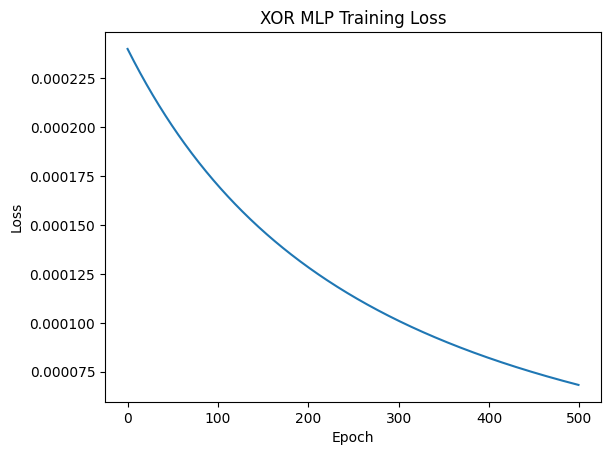

In [10]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'])
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("XOR MLP Training Loss")
plt.show()

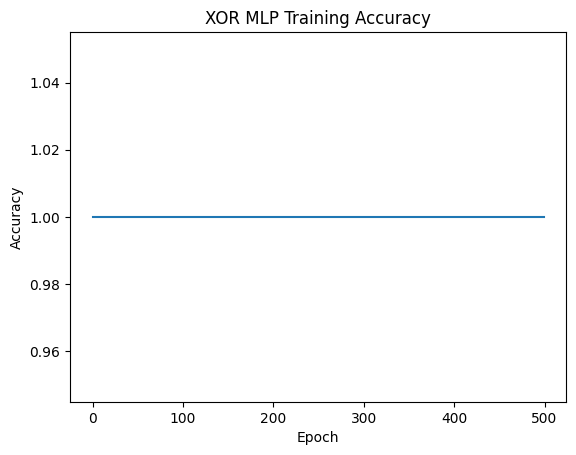

In [11]:
plt.plot(history.history['accuracy'])
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("XOR MLP Training Accuracy")
plt.show()

Step 9 — Final Complete Keras Code

If you want one clean code cell/file to submit, use this

In [12]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# ==========================================
# 1. CREATE XOR DATASET
# ==========================================

X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
], dtype=np.float32)

y = np.array([
    [0],
    [1],
    [1],
    [0]
], dtype=np.float32)


# ==========================================
# 2. BUILD MLP
# ==========================================

model = keras.Sequential([
    layers.Input(shape=(2,)),
    layers.Dense(4, activation='tanh'),
    layers.Dense(1, activation='sigmoid')
])


# ==========================================
# 3. COMPILE MODEL
# ==========================================

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.1),
    loss='binary_crossentropy',
    metrics=['accuracy']
)


# ==========================================
# 4. TRAIN MODEL
# ==========================================

history = model.fit(
    X,
    y,
    epochs=500,
    verbose=0
)


# ==========================================
# 5. EVALUATE MODEL
# ==========================================

loss, accuracy = model.evaluate(
    X,
    y,
    verbose=0
)

print("Final Loss:", loss)
print("Final Accuracy:", accuracy)


# ==========================================
# 6. PREDICT XOR
# ==========================================

predictions = model.predict(X, verbose=0)

print("\nXOR Predictions:")

for i in range(4):

    probability = float(predictions[i][0])

    predicted_class = 1 if probability >= 0.5 else 0

    print(
        "Input:", X[i].astype(int),
        "Probability:", round(probability, 4),
        "Predicted:", predicted_class,
        "Actual:", int(y[i][0])
    )

Final Loss: 0.0006704656407237053
Final Accuracy: 1.0

XOR Predictions:
Input: [0 0] Probability: 0.0 Predicted: 0 Actual: 0
Input: [0 1] Probability: 0.9994 Predicted: 1 Actual: 1
Input: [1 0] Probability: 0.9992 Predicted: 1 Actual: 1
Input: [1 1] Probability: 0.0012 Predicted: 0 Actual: 0


Step 10 — Conclusion for your Lab Record

You need to put the code and results followed by a conclusion in your lab manual.

Conclusion:

The XOR Boolean function was successfully implemented using a Multi-Layer Perceptron (MLP). The network used two input neurons, a hidden layer with Tanh activation, and one output neuron with Sigmoid activation. Binary Cross-Entropy was used as the loss function and Adam was used as the optimizer. After training, the model correctly predicted the four XOR input combinations, demonstrating that an MLP can learn a non-linear relationship such as XOR.